# OBS003 — ALMA Image Analysis of ASPECS C19

## Scientific Objective

Investigate the ALMA continuum emission associated with ASPECS C19 and compare it with optical and infrared observations to characterize the galaxy's morphology, environment, and dust distribution.

---

### Target

ASPECS C19

RA (J2000): 03:32:36.19

Dec (J2000): −27:46:28.0

Adopted Redshift:

z = 2.574

---

## Planned Products

- ALMA continuum image
- FITS header summary
- Beam properties
- Pixel scale
- Continuum cutout
- Flux measurements
- JWST overlay
- HST overlay
- Scientific interpretation

In [1]:
# =====================================
# Setup 1 – Imports
# =====================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astroquery.mast import Observations

from astropy.coordinates import SkyCoord
import astropy.units as u

from astropy.table import Table

In [2]:
# ======================================
# Setup 2 — Project Paths
# ======================================

PROJECT = Path.cwd().parent

DATA = PROJECT / "data"
FIGURES = PROJECT / "figures" / "obs003"
CATALOGS = DATA / "catalogs"
IMAGERY = DATA / "imagery"

FIGURES.mkdir(parents=True, exist_ok=True)

print(PROJECT)
print(IMAGERY)

/home/glenn/Projects/CosmicIntelligenceLab
/home/glenn/Projects/CosmicIntelligenceLab/data/imagery


In [3]:
# ======================================
# Setup 3 — Targets
# ======================================

c19 = SkyCoord(
    "03h32m36.19s",
    "-27d46m28.0s",
    frame="icrs"
)

c19_z = 2.574

print(c19)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.15079167, -27.77444444)>


In [4]:
# ======================================
# Setup 4 — Existing Images
# ======================================

for f in sorted(IMAGERY.rglob("*")):
    print(f.relative_to(IMAGERY))

README.md
alma
derived
derived/ai_bright_galaxy_population.png
hst
hst/hudf_f350lp_drz.fits.gz
hst/hudf_f350lp_preview.png
jwst
jwst/jwst_f200w_clean.png
jwst/jwst_f200w_preview.png


In [5]:
# ======================================
# Setup 5 — Metadata
# ======================================

OBS_ID = "OBS003"

TARGET = "ASPECS C19"

ALMA_PRODUCT = "Band 6 1.2 mm continuum mosaic"

print(OBS_ID)
print(TARGET)
print(ALMA_PRODUCT)

OBS003
ASPECS C19
Band 6 1.2 mm continuum mosaic


In [6]:
# ======================================
# Setup 6 — Archival Information
# ======================================

ARCHIVE = (
    "https://almascience.nao.ac.jp/"
    "almadata/lp/ASPECS/"
    "member.uid___A001_X87c_X21e.lp_walter/"
)

README = "member.uid___A001_X87c_X21e.lp_walter.README.txt"

print(ARCHIVE)
print(README)

https://almascience.nao.ac.jp/almadata/lp/ASPECS/member.uid___A001_X87c_X21e.lp_walter/
member.uid___A001_X87c_X21e.lp_walter.README.txt


In [7]:
# ======================================
# Phase 3A — Download the ALMA Continuum Mosaic
# ======================================

import requests

ALMA_DIR = PROJECT / "data" / "raw" / "alma"
ALMA_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = (
    "https://almascience.nrao.edu/"
    "almadata/lp/ASPECS/"
    "member.uid___A001_X87c_X21e_lp_walter/"
)

FILENAME = (
    "member.uid___A001_X87c_X21e.lp_walter."
    "aspecs1mm.cont.nat.image.clean.pbcor.fits"
)

URL = BASE_URL + FILENAME

outfile = ALMA_DIR / FILENAME

print(URL)

if outfile.exists():
    print("Already downloaded.")
else:

    with requests.get(URL, stream=True, timeout=120) as r:
        r.raise_for_status()

        total = int(r.headers.get("Content-Length", 0))
        downloaded = 0

        with open(outfile, "wb") as f:

            for chunk in r.iter_content(1024 * 1024):

                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)

                    if total:
                        print(
                            f"\r{downloaded/total*100:5.1f}% ",
                            end=""
                        )

print("\nDone.")
print(outfile)
print(f"{outfile.stat().st_size/1024**2:.2f} MB")

https://almascience.nrao.edu/almadata/lp/ASPECS/member.uid___A001_X87c_X21e_lp_walter/member.uid___A001_X87c_X21e.lp_walter.aspecs1mm.cont.nat.image.clean.pbcor.fits
Already downloaded.

Done.
/home/glenn/Projects/CosmicIntelligenceLab/data/raw/alma/member.uid___A001_X87c_X21e.lp_walter.aspecs1mm.cont.nat.image.clean.pbcor.fits
2.70 MB


In [8]:
# ==========================================================
# Phase 3B
# Inspect FITS Header
# ==========================================================

alma_file = (
    DATA
    / "raw"
    / "alma"
    / "member.uid___A001_X87c_X21e.lp_walter."
      "aspecs1mm.cont.nat.image.clean.pbcor.fits"
)

hdul = fits.open(alma_file)

hdul.info()

Filename: /home/glenn/Projects/CosmicIntelligenceLab/data/raw/alma/member.uid___A001_X87c_X21e.lp_walter.aspecs1mm.cont.nat.image.clean.pbcor.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      79   (840, 840, 1, 1)   float32   


In [9]:
# ==========================================================
# Phase 3B.1
# Inspect Important Header Keywords
# ==========================================================

header = hdul[0].header

keys = [
    "OBJECT",
    "TELESCOP",
    "INSTRUME",
    "BUNIT",
    "BMAJ",
    "BMIN",
    "BPA",
    "CRVAL1",
    "CRVAL2",
    "CRPIX1",
    "CRPIX2",
    "CDELT1",
    "CDELT2",
    "CTYPE1",
    "CTYPE2",
]

for key in keys:

    if key in header:
        print(f"{key:10s} : {header[key]}")

OBJECT     : UDF_mosaic_1mm
TELESCOP   : ALMA
INSTRUME   : ALMA
BUNIT      : Jy/beam
BMAJ       : 0.0004258893595801
BMIN       : 0.0003002514110671
BPA        : -84.46213531494
CRVAL1     : 53.16041651968
CRVAL2     : -27.78333311299
CRPIX1     : 421.0
CRPIX2     : 421.0
CDELT1     : -5.5555555543e-05
CDELT2     : 5.5555555543e-05
CTYPE1     : RA---SIN
CTYPE2     : DEC--SIN


In [10]:
# ==========================================================
# Phase 3D
# Locate C19 in the ALMA mosaic
# ==========================================================

from astropy.wcs import WCS

image = hdul[0].data[0, 0]

wcs = WCS(hdul[0].header).celestial

x, y = wcs.world_to_pixel(c19)

print(f"C19 pixel position:")
print(f"x = {x:.2f}")
print(f"y = {y:.2f}")

C19 pixel position:
x = 573.23
y = 579.94


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


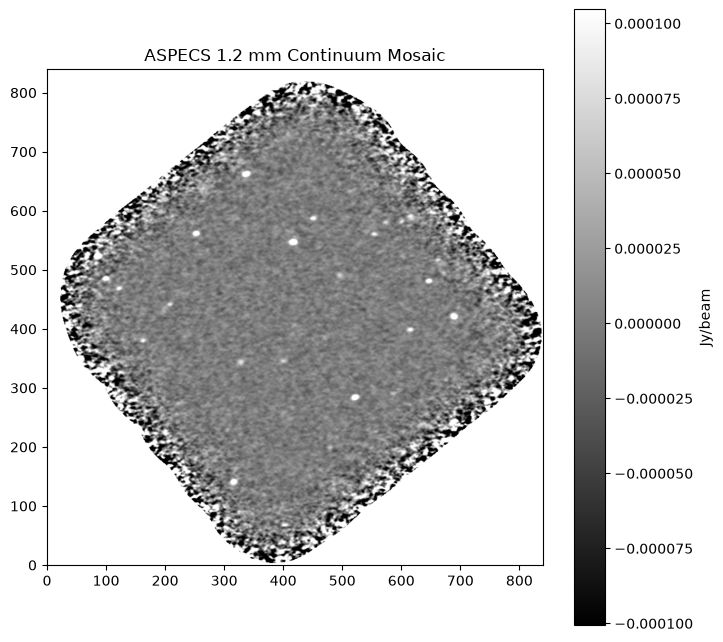

In [11]:
# ==========================================================
# Phase 3C
# Display the ALMA Continuum Mosaic
# ==========================================================

image = hdul[0].data[0, 0]

from astropy.visualization import ImageNormalize, ZScaleInterval

alma_norm = ImageNormalize(
    image,
    interval=ZScaleInterval()
)

plt.figure(figsize=(8,8))

plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    norm=alma_norm
)

plt.colorbar(label=header["BUNIT"])

plt.title("ASPECS 1.2 mm Continuum Mosaic")

plt.show()

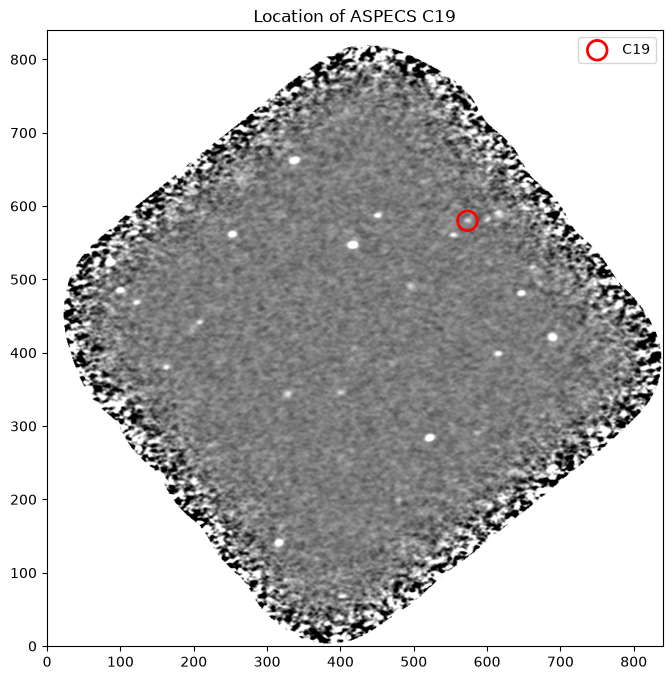

In [12]:
# ==========================================================
# Phase 3D.1 - Location of ASPECS C19
# ==========================================================

plt.figure(figsize=(8, 8))

plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    norm=alma_norm
)

plt.scatter(
    x,
    y,
    s=200,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
    label="C19"
)

plt.legend()

plt.title("Location of ASPECS C19")

plt.show()

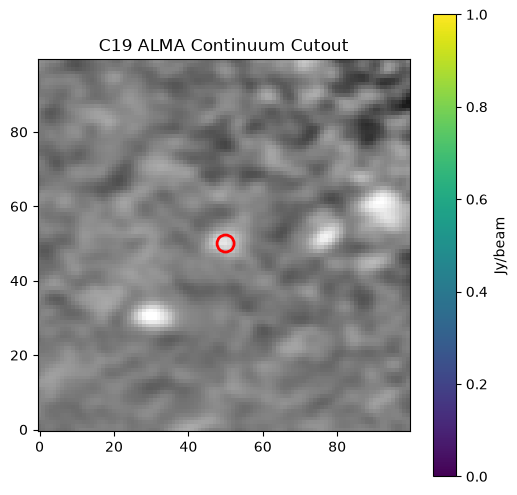

In [13]:
# ==========================================================
# Phase 3E
# Extract a C19 cutout
# ==========================================================

size = (100, 100)   # pixels

cutout = Cutout2D(
    image,
    position=(x, y),
    size=size,
    wcs=wcs
)

plt.figure(figsize=(6, 6))

plt.imshow(
    cutout.data,
    origin="lower",
    cmap="gray",
    norm=alma_norm
)

plt.scatter(
    50,
    50,
    s=150,
    facecolors="none",
    edgecolors="red",
    linewidths=2
)

plt.title("C19 ALMA Continuum Cutout")

plt.colorbar(label=header["BUNIT"])

plt.show()

In [14]:
# ==========================================================
# Phase 3F
# Basic measurements
# ==========================================================

print("Minimum :", np.min(cutout.data))
print("Maximum :", np.max(cutout.data))
print("Mean    :", np.mean(cutout.data))
print("Median  :", np.median(cutout.data))
print("Std dev :", np.std(cutout.data))

Minimum : -8.080516e-05
Maximum : 0.000114004804
Mean    : 8.298843e-07
Median  : 5.1300375e-10
Std dev : 1.8322069e-05


In [15]:
# ==========================================================
# Phase 3F.1
# ==========================================================

center = cutout.data[40:60, 40:60]

peak = np.max(center)

peak_y, peak_x = np.unravel_index(
    np.argmax(center),
    center.shape
)

print("Peak value:", peak)
print("Pixel:", peak_x, peak_y)

Peak value: 8.501872e-05
Pixel: 10 10


In [16]:
# ==========================================================
# Phase 3F.1
# 20 x 20 region around C19
# ==========================================================

peak = np.max(center)

py, px = np.unravel_index(
    np.argmax(center),
    center.shape
)

print("Peak in 20x20:", px, py)

print("Peak in cutout:", px + 40, py + 40)

Peak in 20x20: 10 10
Peak in cutout: 50 50


In [17]:
# ==========================================================
# Phase 3F.2
# Estimate Local RMS
# ==========================================================

rms = np.std(cutout.data)

print(f"Local RMS = {rms:.2e} Jy/beam")

peak = cutout.data[50, 50]

print(f"Peak Flux = {peak:.2e} Jy/beam")

print(f"S/N = {peak/rms:.2f}")

Local RMS = 1.83e-05 Jy/beam
Peak Flux = 8.50e-05 Jy/beam
S/N = 4.64


In [18]:
# ==========================================================
# Phase 3G
# Beam Properties
# ==========================================================

beam_keys = [
    "BMAJ",
    "BMIN",
    "BPA",
    "BUNIT",
]

for key in beam_keys:
    print(f"{key:6s} : {header[key]}")

BMAJ   : 0.0004258893595801
BMIN   : 0.0003002514110671
BPA    : -84.46213531494
BUNIT  : Jy/beam


In [19]:
# ==========================================================
# Phase 3G.1
# ==========================================================

from astropy.wcs.utils import proj_plane_pixel_scales

pixel_scales = proj_plane_pixel_scales(wcs)

pixel_scale_arcsec = pixel_scales[0] * 3600

print(pixel_scale_arcsec)

0.1999999999548


In [20]:
# ==========================================================
# Phase 3G.1 - ALMA continuum + beam
# ==========================================================

beam_major_arcsec = header["BMAJ"] * 3600
beam_minor_arcsec = header["BMIN"] * 3600

beam_major_pix = beam_major_arcsec / pixel_scale_arcsec
beam_minor_pix = beam_minor_arcsec / pixel_scale_arcsec

print(f"Beam major = {beam_major_arcsec:.3f} arcsec")
print(f"Beam minor = {beam_minor_arcsec:.3f} arcsec")

print(f"Beam major = {beam_major_pix:.2f} pixels")
print(f"Beam minor = {beam_minor_pix:.2f} pixels")

Beam major = 1.533 arcsec
Beam minor = 1.081 arcsec
Beam major = 7.67 pixels
Beam minor = 5.40 pixels


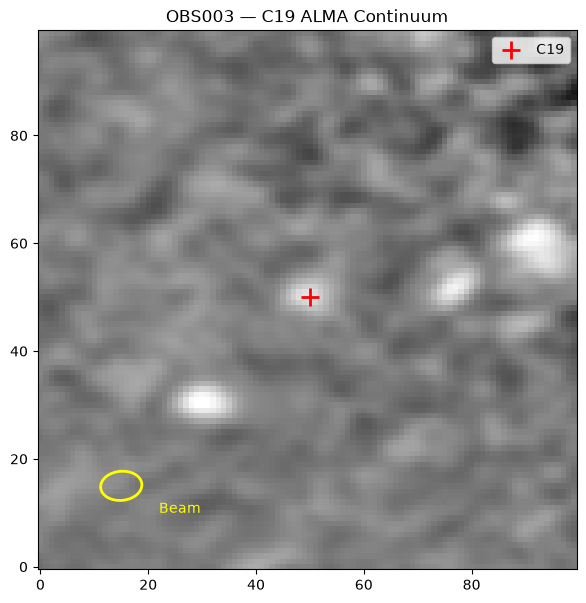

In [21]:
# ==========================================================
# Phase 3G
# C19 ALMA Continuum
# ==========================================================

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(7,7))

ax.imshow(
    cutout.data,
    origin="lower",
    cmap="gray",
    norm=alma_norm
)

# Mark the position of C19
ax.scatter(
    50,
    50,
    marker="+",
    s=180,
    color="red",
    linewidths=2,
    label="C19"
)

# Draw the synthesized beam
beam = Ellipse(
    xy=(15,15),
    width=beam_minor_pix,
    height=beam_major_pix,
    angle=header["BPA"],
    edgecolor="yellow",
    facecolor="none",
    linewidth=2
)

ax.add_patch(beam)

# Label the beam
ax.text(
    22,
    10,
    "Beam",
    color="yellow",
    fontsize=10
)

ax.set_title("OBS003 — C19 ALMA Continuum")

ax.legend()

plt.show()

In [22]:
# ==========================================================
# Phase 3H
# 2D Gaussian Fit
# ==========================================================

from astropy.modeling import models, fitting

In [23]:
# Create coordinate arrays

ny, nx = cutout.data.shape

y, x = np.mgrid[:ny, :nx]

In [24]:
# Initial Gaussian estimate

initial = models.Gaussian2D(
    amplitude=cutout.data.max(),
    x_mean=50,
    y_mean=50,
    x_stddev=3,
    y_stddev=3,
    theta=0
)

In [25]:
fit = fitting.LevMarLSQFitter()

gauss = fit(
    initial,
    x,
    y,
    cutout.data
)

In [26]:
print("Amplitude :", gauss.amplitude.value)
print()

print("Centroid")

print("x =", gauss.x_mean.value)
print("y =", gauss.y_mean.value)

print()

print("Sigma")

print("x =", gauss.x_stddev.value)
print("y =", gauss.y_stddev.value)

print()

print("Theta (deg)")

print(np.degrees(gauss.theta.value))

Amplitude : 8.466775944283975e-05

Centroid
x = 50.0327252296452
y = 50.33417190739765

Sigma
x = 3.3908182913485767
y = 2.547720349673103

Theta (deg)
18.865620965244535


In [27]:
FWHM = 2.3548

fwhm_x = gauss.x_stddev.value * FWHM
fwhm_y = gauss.y_stddev.value * FWHM

print(f"FWHM x = {fwhm_x:.2f} pixels")
print(f"FWHM y = {fwhm_y:.2f} pixels")

print()

print(f"Beam = {beam_major_pix:.2f} × {beam_minor_pix:.2f} pixels")

FWHM x = 7.98 pixels
FWHM y = 6.00 pixels

Beam = 7.67 × 5.40 pixels


In [28]:
# ==========================================================
# Phase 3H
# Beam Deconvolution
# ==========================================================

import numpy as np

major_intrinsic = np.sqrt(max(0, fwhm_x**2 - beam_major_pix**2))
minor_intrinsic = np.sqrt(max(0, fwhm_y**2 - beam_minor_pix**2))

print(f"Intrinsic major = {major_intrinsic:.2f} pixels")
print(f"Intrinsic minor = {minor_intrinsic:.2f} pixels")

print()

print(f"Intrinsic major = {major_intrinsic * pixel_scale_arcsec:.2f} arcsec")
print(f"Intrinsic minor = {minor_intrinsic * pixel_scale_arcsec:.2f} arcsec")

Intrinsic major = 2.23 pixels
Intrinsic minor = 2.60 pixels

Intrinsic major = 0.45 arcsec
Intrinsic minor = 0.52 arcsec


In [29]:
# ==========================================================
# Phase 3I
# Aperture Flux Measurement
# ==========================================================

from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry

# Aperture centered on fitted position
position = [(gauss.x_mean.value, gauss.y_mean.value)]

# Radius in pixels
radius = 8

aperture = CircularAperture(position, r=radius)

phot = aperture_photometry(cutout.data, aperture)

phot

id,x_center,y_center,aperture_sum
int64,float64,float64,float64
1,50.0327252296452,50.33417190739765,0.004353420558974072


In [30]:
# ==========================================================
# Phase 3I
# Beam Area
# ==========================================================

beam_area_pix = 1.1331 * beam_major_pix * beam_minor_pix

print(f"Beam area = {beam_area_pix:.2f} pixels")

Beam area = 46.95 pixels


In [31]:
# ==========================================================
# Phase 3I
# Integrated Flux Density
# ==========================================================

integrated_flux = phot["aperture_sum"][0] / beam_area_pix

print(f"Integrated Flux = {integrated_flux:.6e} Jy")
print(f"Integrated Flux = {integrated_flux*1000:.3f} mJy")

print()
print(f"Peak Flux       = {gauss.amplitude.value:.6e} Jy/beam")
print(f"Peak Flux       = {gauss.amplitude.value*1000:.3f} mJy/beam")

Integrated Flux = 9.273326e-05 Jy
Integrated Flux = 0.093 mJy

Peak Flux       = 8.466776e-05 Jy/beam
Peak Flux       = 0.085 mJy/beam


# =================================
## Phase 4A – Acquire JWST Science Data
# =================================

In [32]:
obs = Observations.query_criteria(
    coordinates="03h32m36.19s -27d46m28.0s",
    radius="2 arcmin",
    obs_collection="JWST"
)

print(len(obs))
print(obs.colnames)

10492
['intentType', 'obs_collection', 'provenance_name', 'instrument_name', 'project', 'filters', 'wave_region', 'target_name', 'target_classification', 'obs_id', 's_ra', 's_dec', 'dataproduct_type', 'proposal_pi', 'calib_level', 't_min', 't_max', 't_exptime', 'wavelength_region', 'em_min', 'em_max', 'obs_title', 't_obs_release', 'proposal_id', 'proposal_type', 'sequence_number', 's_region', 'jpegURL', 'dataURL', 'dataRights', 'mtFlag', 'srcDen', 'obsid', 'objID', 'wave_min', 'wave_max', 'objID1', 'distance']


In [33]:
# ==========================================================
# Filter to NIRCam F200W images
# ==========================================================

f200w = obs[
    (obs["instrument_name"] == "NIRCAM/IMAGE") &
    (obs["filters"] == "F200W")
]

print("Number of F200W observations:", len(f200w))

f200w["obs_id",
      "proposal_id",
      "target_name",
      "filters",
      "calib_level"][:20]

Number of F200W observations: 34


obs_id,proposal_id,target_name,filters,calib_level
str66,str5,str30,str13,int64
jw01180-o220_t220_nircam_clear-f200w,1180,MEDS0002a,F200W,3
jw01180-o015_t012_nircam_clear-f200w,1180,POINTINGTHREE-A,F200W,3
jw01286-o007_t012_nircam_clear-f200w,1286,1286_7and8_trim_final_clean,F200W,3
jw06541-o002_t002_nircam_clear-f200w,6541,JADES-Deep2,F200W,3
jw01180-o013_t011_nircam_clear-f200w,1180,POINTINGTHREE-B,F200W,3
jw01180-o018_t014_nircam_clear-f200w,1180,POINTINGFOUR-A,F200W,3
jw01176-o131_t016_nircam_clear-f200w,1176,WFC3-ERS-FIELD,F200W,3
jw08060-o006_t006_nircam_clear-f200w,8060,NIRCam-Epoch-3b,F200W,3
jw06541-o005_t005_nircam_clear-f200w,6541,JADES-Deep5,F200W,3


In [34]:
# ==========================================================
# Find the closest F200W observations
# ==========================================================

f200w.sort("distance")

f200w[
    "distance",
    "proposal_id",
    "target_name",
    "obs_id",
    "calib_level"
][:15]

distance,proposal_id,target_name,obs_id,calib_level
float64,str5,str30,str66,int64
0.0,1180,MEDS0002a,jw01180-o220_t220_nircam_clear-f200w,3
0.0,1180,POINTINGTHREE-A,jw01180-o015_t012_nircam_clear-f200w,3
0.0,1180,MEDS0006,jw01180-o024_t020_nircam_clear-f200w,3
0.0,1180,POINTINGTHREE-B,jw01180-o013_t011_nircam_clear-f200w,3
0.0,5324,JADES-SNIa,jw05324-o027_t022_nircam_clear-f200w,3
0.0,7336,HUDF-WFSS-Center,jw07336-o001_t001_nircam_clear-f200w,3
0.0,6541,JADES-Deep5,jw06541-o005_t005_nircam_clear-f200w,3
0.0,8060,NIRCam-Epoch-2a,jw08060-o003_t003_nircam_clear-f200w,3
0.2214283040083028,5324,JADES-SNIa,jw05324-o026_t022_nircam_clear-f200w,3


In [35]:
# ==========================================================
# Retrieve JADES Deep5 Products
# ==========================================================

deep5 = f200w[
    f200w["target_name"] == "JADES-Deep5"
][0]

products = Observations.get_product_list(deep5)

print(len(products))

products.colnames

774


['obsID',
 'obs_collection',
 'dataproduct_type',
 'obs_id',
 'description',
 'type',
 'dataURI',
 'productType',
 'productGroupDescription',
 'productSubGroupDescription',
 'productDocumentationURL',
 'project',
 'prvversion',
 'proposal_id',
 'productFilename',
 'size',
 'parent_obsid',
 'dataRights',
 'calib_level',
 'filters']

In [36]:
products[
    "productFilename",
    "productType",
    "calib_level"
][:40]

productFilename,productType,calib_level
str50,str9,int64
jw06541005001_02101_00001_nrca4_trapsfilled.fits,AUXILIARY,2
jw06541-o005_20260803t134053_image2_00087_asn.json,INFO,2
jw06541_20260803t134053_pool.csv,INFO,2
jw06541005001_02101_00001_nrca4_uncal.jpg,PREVIEW,1
jw06541005001_02101_00001_nrca4_cal.jpg,PREVIEW,2
jw06541005001_02101_00001_nrca4_i2d.jpg,PREVIEW,2
jw06541005001_02101_00001_nrca4_o005_crf.jpg,PREVIEW,2
jw06541005001_02101_00001_nrca4_rate.jpg,PREVIEW,2
jw06541005001_02101_00001_nrca4_rateints.jpg,PREVIEW,2


In [37]:
# ==========================================================
# Find the calibrated JWST mosaics
# ==========================================================

i2d = products[
    np.char.endswith(
        products["productFilename"].astype(str),
        "_i2d.fits"
    )
]

print("Number of i2d products:", len(i2d))

i2d[
    "productFilename",
    "productType",
    "calib_level"
]

Number of i2d products: 49


productFilename,productType,calib_level
str50,str9,int64
jw06541005001_02101_00001_nrca4_i2d.fits,SCIENCE,2
jw06541005001_02101_00001_nrcb4_i2d.fits,SCIENCE,2
jw06541005001_02101_00002_nrcb3_i2d.fits,SCIENCE,2
jw06541005001_02101_00001_nrca3_i2d.fits,SCIENCE,2
jw06541005001_02101_00001_nrcb3_i2d.fits,SCIENCE,2
jw06541005001_02101_00001_nrcb2_i2d.fits,SCIENCE,2
jw06541005001_02101_00001_nrcb1_i2d.fits,SCIENCE,2
jw06541005001_02101_00001_nrca1_i2d.fits,SCIENCE,2
jw06541005001_02101_00001_nrca2_i2d.fits,SCIENCE,2


In [38]:
# ==========================================================
# Download the JADES Deep5 F200W science mosaic
# ==========================================================

science = products[
    products["productFilename"] ==
    "jw06541-o005_t005_nircam_clear-f200w_i2d.fits"
]

manifest = Observations.download_products(
    science,
    download_dir=DATA / "raw" / "jwst"
)

manifest

INFO: Found cached file /home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/mastDownload/JWST/jw06541-o005_t005_nircam_clear-f200w/jw06541-o005_t005_nircam_clear-f200w_i2d.fits with expected size 1387667520. [astroquery.query]


Local Path,Status,Message,URL
str157,str8,object,object
/home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/mastDownload/JWST/jw06541-o005_t005_nircam_clear-f200w/jw06541-o005_t005_nircam_clear-f200w_i2d.fits,COMPLETE,None,None


In [39]:
# ==========================================================
# Phase 4B
# Open the JWST Science Mosaic
# ==========================================================

JWST_FILE = (
    DATA /
    "raw" /
    "jwst" /
    "jw06541-o005_t005_nircam_clear-f200w_i2d.fits"
)

hdul = fits.open(JWST_FILE)

hdul.info()

Filename: /home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/jw06541-o005_t005_nircam_clear-f200w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     280   ()      
  1  SCI           1 ImageHDU        75   (9884, 4386)   float32   
  2  ERR           1 ImageHDU        10   (9884, 4386)   float32   
  3  CON           1 ImageHDU        10   (9884, 4386, 2)   int32   
  4  WHT           1 ImageHDU         9   (9884, 4386)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (9884, 4386)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (9884, 4386)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (9884, 4386)   float32   
  8  HDRTAB        1 BinTableHDU    536   48R x 263C   [23A, 5A, 3A, 45A, 7A, 13A, 3A, 5A, 5A, 7A, 10A, 4A, L, D, D, 32A, 50A, 104A, 13A, 2A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 11A, 1A, 5A, D, D, D, D, D, D, D, D, 6A, 5A, 1A, 

In [40]:
# ==========================================================
# Phase 4B
# Load JWST Science Image
# ==========================================================

jwst_image = hdul["SCI"].data

jwst_header = hdul["SCI"].header

jwst_wcs = WCS(jwst_header)

print(jwst_image.shape)
print(jwst_image.dtype)

(4386, 9884)
>f4


Set DATE-AVG to '2024-01-01T09:29:55.361' from MJD-AVG.
Set DATE-END to '2024-01-01T09:56:08.363' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.851392 from OBSGEO-[XYZ].
Set OBSGEO-H to 1694081725.647 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [41]:
# ==========================================================
# Locate C19 in the JWST mosaic
# ==========================================================

jwst_x, jwst_y = jwst_wcs.world_to_pixel(c19)

print(f"x = {jwst_x:.2f}")
print(f"y = {jwst_y:.2f}")

x = 3875.97
y = 315.60


In [42]:
jwst_cutout = Cutout2D(
    jwst_image,
    (jwst_x, jwst_y),
    (200, 200),
    wcs=jwst_wcs
)

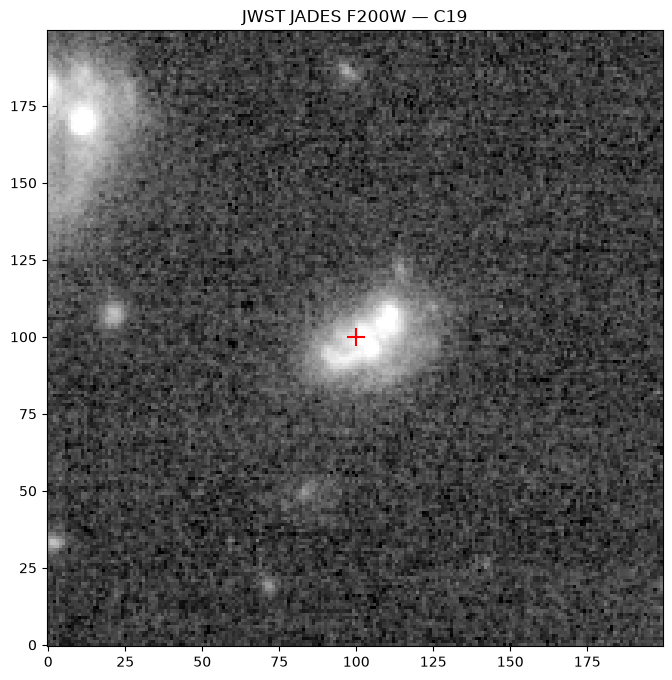

In [43]:
from astropy.visualization import AsinhStretch
from astropy.visualization import PercentileInterval

jwst_norm = ImageNormalize(
    jwst_cutout.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch()
)

plt.figure(figsize=(8, 8))

plt.imshow(
    jwst_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

plt.scatter(
    100,
    100,
    marker="+",
    color="red",
    s=150
)

plt.title("JWST JADES F200W — C19")

plt.show()

# ===========================================
# Phase 4C – Compare ALMA and JWST Morphology
# ===========================================

In [44]:
# ==========================================================
# Phase 4C
# Reproject the ALMA image onto the JWST cutout
# ==========================================================

from reproject import reproject_interp

alma_on_jwst, footprint = reproject_interp(
    (image, wcs),
    jwst_cutout.wcs,
    shape_out=jwst_cutout.data.shape
)

print(alma_on_jwst.shape)

(200, 200)


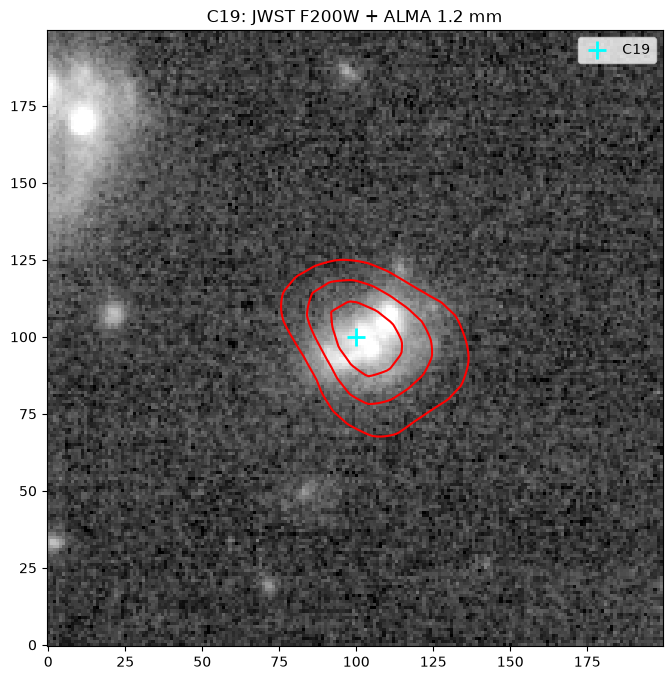

In [45]:
# ==========================================================
# Phase 4C
# JWST + ALMA Overlay
# ==========================================================

from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch
)

jwst_norm = ImageNormalize(
    jwst_cutout.data,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch()
)

fig, ax = plt.subplots(figsize=(8,8))

# JWST background
ax.imshow(
    jwst_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

# ALMA contours
levels = [3e-5, 5e-5, 7e-5]

ax.contour(
    alma_on_jwst,
    levels=levels,
    colors="red",
    linewidths=1.5
)

# Published C19 position
ax.scatter(
    100,
    100,
    marker="+",
    s=180,
    color="cyan",
    linewidths=2,
    label="C19"
)

ax.set_title("C19: JWST F200W + ALMA 1.2 mm")

ax.legend()

plt.show()

In [46]:
# ==========================================================
# Phase 4D
# Measure the JWST centroid
# ==========================================================

from photutils.centroids import centroid_com

# small box around the galaxy
stamp = jwst_cutout.data[80:120, 80:120]

cx, cy = centroid_com(stamp)

print(f"x = {cx:.3f}")
print(f"y = {cy:.3f}")

x = 20.645
y = 19.363


In [47]:
jwst_x = cx + 80
jwst_y = cy + 80

print(jwst_x)
print(jwst_y)

100.64537421620386
99.36275793096583


In [48]:
# ==========================================================
# ALMA Gaussian centroid
# ==========================================================

alma_x = 50.0327252296452
alma_y = 50.33417190739765

In [49]:
dx = jwst_x - alma_x
dy = jwst_y - alma_y

offset_pixels = np.hypot(dx, dy)

In [50]:
dx = jwst_x - alma_x
dy = jwst_y - alma_y

offset_pixels = np.hypot(dx, dy)

print(f"Δx = {dx:.3f} pixels")
print(f"Δy = {dy:.3f} pixels")
print(f"Offset = {offset_pixels:.3f} pixels")

Δx = 50.613 pixels
Δy = 49.029 pixels
Offset = 70.466 pixels


In [51]:
# ==========================================================
# Phase 4D
# Convert ALMA and JWST centroids to sky coordinates
# ==========================================================

# ALMA Gaussian centroid in the 100x100 ALMA cutout

alma_centroid_sky = cutout.wcs.pixel_to_world(
    alma_x,
    alma_y
)

# JWST centroid in the 200x200 JWST cutout
jwst_centroid_sky = jwst_cutout.wcs.pixel_to_world(
    jwst_x,
    jwst_y
)

print("ALMA centroid:")
print(alma_centroid_sky)

print()
print("JWST centroid:")
print(jwst_centroid_sky)

ALMA centroid:
<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (53.15074487, -27.77442532)>

JWST centroid:
<SkyCoord (ICRS): (ra, dec) in deg
    (53.15078534, -27.77444173)>


In [52]:
# ==========================================================
# Phase 4D
# Convert ALMA and JWST centroids to sky coordinates
# ==========================================================

# ALMA Gaussian centroid in the 100x100 ALMA cutout

alma_centroid_sky = cutout.wcs.pixel_to_world(
    alma_x,
    alma_y
)

# JWST centroid in the 200x200 JWST cutout
jwst_centroid_sky = jwst_cutout.wcs.pixel_to_world(
    jwst_x,
    jwst_y
)

print("ALMA centroid:")
print(alma_centroid_sky)

print()

print("JWST centroid:")
print(jwst_centroid_sky)

ALMA centroid:
<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (53.15074487, -27.77442532)>

JWST centroid:
<SkyCoord (ICRS): (ra, dec) in deg
    (53.15078534, -27.77444173)>


In [53]:
# ==========================================================
# Phase 4D
# Measure the ALMA–JWST angular offset
# ==========================================================

offset = alma_centroid_sky.separation(jwst_centroid_sky)

print(f"Angular offset = {offset.arcsec:.4f} arcsec")

Angular offset = 0.1565 arcsec


In [54]:
# ==========================================================
# Phase 4D
# Angular scale at the redshift of C19
# ==========================================================

from astropy.cosmology import Planck18 as cosmo

z_c19 = 2.574

kpc_per_arcsec = cosmo.kpc_proper_per_arcmin(z_c19) / 60.0

print(f"Angular scale = {kpc_per_arcsec:.3f}")

Angular scale = 8.211 kpc / arcmin


In [55]:
# ==========================================================
# Phase 4D
# Physical ALMA–JWST centroid offset
# ==========================================================

physical_offset_kpc = offset.arcsec * kpc_per_arcsec.value

print(f"Angular offset = {offset.arcsec:.4f} arcsec")
print(f"Physical offset = {physical_offset_kpc:.2f} kpc")

Angular offset = 0.1565 arcsec
Physical offset = 1.29 kpc


In [56]:
# ==========================================================
# Phase 4E.1
# Detect the galaxy in the JWST cutout
# ==========================================================

from astropy.stats import sigma_clipped_stats
from photutils.segmentation import (
    detect_threshold,
    detect_sources
)

# Estimate background statistics
mean, median, std = sigma_clipped_stats(jwst_cutout.data)

print(f"Background median = {median:.4e}")
print(f"Background sigma  = {std:.4e}")

# 3-sigma detection threshold
threshold = median + 3 * std

segm = detect_sources(
    jwst_cutout.data,
    threshold,
    n_pixels=20
)

segm

Background median = 1.4220e-01
Background sigma  = 7.6922e-03


<photutils.segmentation.core.SegmentationImage>
shape: (200, 200)
n_labels: 6
labels: [1 2 3 4 5 6]

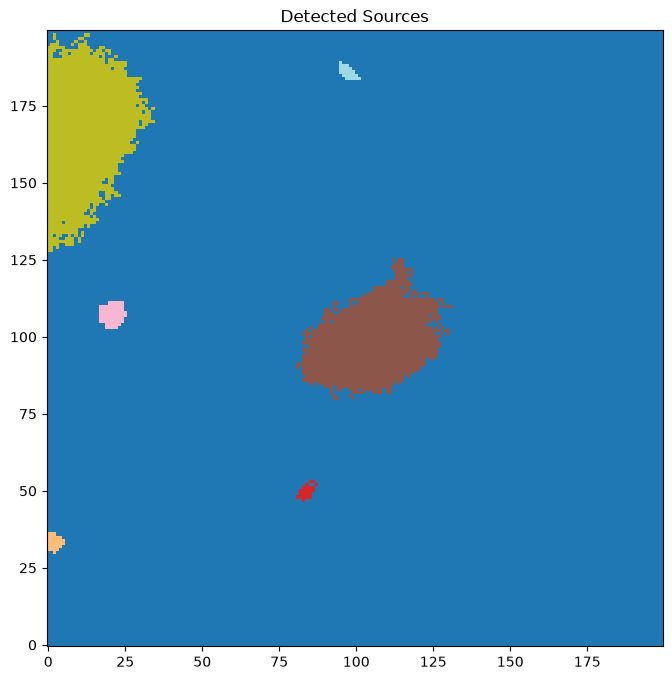

In [57]:
# ==========================================================
# Phase 4E.1
# Display the segmentation map
# ==========================================================

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(
    segm.data,
    origin="lower",
    cmap="tab20"
)

ax.set_title("Detected Sources")

plt.show()

In [58]:
# ==========================================================
# Phase 4E.1
# Build a Source Catalog
# ==========================================================

from photutils.segmentation import SourceCatalog

catalog = SourceCatalog(
    jwst_cutout.data,
    segm
)

tbl = catalog.to_table()

print(tbl.colnames)

['label', 'x_centroid', 'y_centroid', 'sky_centroid', 'bbox_xmin', 'bbox_xmax', 'bbox_ymin', 'bbox_ymax', 'area', 'semimajor_axis', 'semiminor_axis', 'orientation', 'eccentricity', 'min_value', 'max_value', 'segment_flux', 'segment_flux_err', 'kron_flux', 'kron_flux_err']


In [59]:
# ==========================================================
# Phase 4E.1
# Display measured source properties
# ==========================================================

tbl[
    "label",
    "x_centroid",
    "y_centroid",
    "area",
    "semimajor_axis",
    "semiminor_axis",
    "orientation",
    "eccentricity",
    "segment_flux"
]

label,x_centroid,y_centroid,area,semimajor_axis,semiminor_axis,orientation,eccentricity,segment_flux
,,,pix2,pix,pix,deg,,
int32,float64,float64,float64,float64,float64,float64,float64,float64
1,2.012559613005619,33.297400633079775,30.0,1.5739355567072777,1.4849213848391905,286.2993234688214,0.3315295272494011,5.871626377105713
2,83.98344644245732,49.866530626445424,23.0,1.9532397915683002,1.0309425319035685,49.6190537775034,0.8493615027096795,4.008045107126236
3,105.472904467131,99.36393262522841,1237.0,11.65683428909326,7.688707239376586,30.516416991962842,0.7516274063921986,279.7284860610962
4,20.85376666533483,107.22647192957383,64.0,2.2939647349872336,2.1217740143791333,56.79760889094235,0.3801192118235824,12.281909048557281
5,11.901918053451283,166.75717570097703,1525.0,15.684214141991422,7.7236062700459325,82.50920352323149,0.8703438022442833,339.785102263093
6,97.33440007224677,185.94250323329965,23.0,2.023835225847807,0.8993281598574202,321.2419867115548,0.8958442051129795,4.226055607199669


Saved: /home/glenn/Projects/CosmicIntelligenceLab/figures/obs003/fig2_c19_jwst_stellar_morphology.png


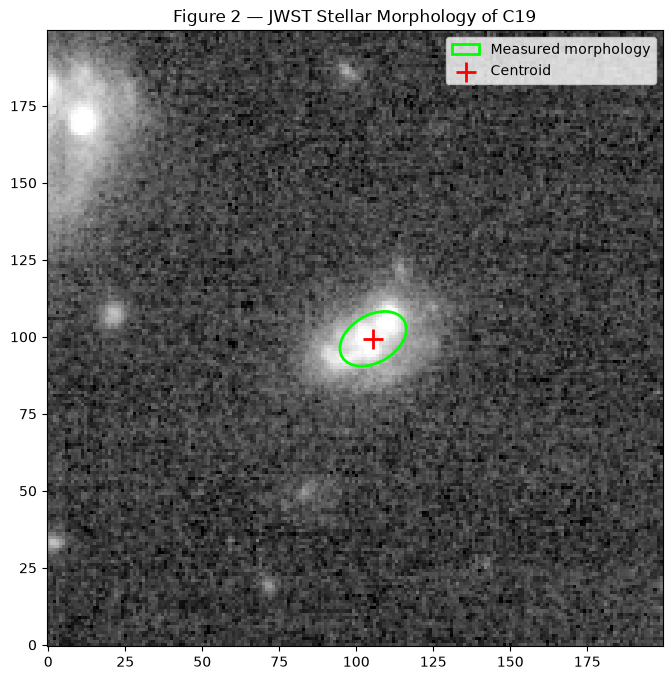

In [60]:
# ==========================================================
# Figure 2
# JWST Morphology of C19
# ==========================================================

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(8, 8))

# Display the JWST cutout
ax.imshow(
    jwst_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

# C19 measurements (Row 3)
x0 = 105.472904467131
y0 = 99.36393262522841

a = 11.65683428909326
b = 7.688707239376586

theta = 30.516416991962842

# Draw ellipse
ellipse = Ellipse(
    (x0, y0),
    width=2 * a,
    height=2 * b,
    angle=theta,
    edgecolor="lime",
    facecolor="none",
    linewidth=2,
    label="Measured morphology"
)

ax.add_patch(ellipse)

# Centroid
ax.scatter(
    x0,
    y0,
    marker="+",
    s=220,
    color="red",
    linewidths=2,
    label="Centroid"
)

ax.set_title("Figure 2 — JWST Stellar Morphology of C19")

ax.legend()

# -------------------------------
# Save Figure 2
# -------------------------------
outfile = FIGURES / "fig2_c19_jwst_stellar_morphology.png"

fig.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved: {outfile}")

plt.show()

# Summary of Results

## Scientific Objective

Investigate the ALMA 1.2 mm continuum emission associated with ASPECS C19 and compare it with deep JWST F200W imaging to characterize the galaxy's dust emission, stellar morphology, and spatial alignment.

---

## ALMA Continuum Measurements

| Quantity | Value |
|----------|------:|
| Peak Flux Density | **0.085 mJy beam⁻¹** |
| Integrated Flux Density | **0.093 mJy** |
| Local RMS | **1.83 × 10⁻⁵ Jy beam⁻¹** |
| Signal-to-Noise Ratio | **4.64** |
| Synthesized Beam | **1.53″ × 1.08″** |
| Beam Position Angle | **−84.46°** |
| Gaussian Position Angle | **18.87°** |

---

## JWST Morphology

| Quantity | Value |
|----------|------:|
| Segmentation Sources Detected | **6** |
| Semimajor Axis | **11.66 pixels** |
| Semiminor Axis | **7.69 pixels** |
| Orientation | **30.52°** |
| Eccentricity | **0.752** |

---

## ALMA–JWST Comparison

| Quantity | Value |
|----------|------:|
| Angular Offset | **0.1565 arcsec** |
| Physical Offset | **1.29 kpc** |

---

## Scientific Interpretation

The ALMA continuum source is detected with moderate significance and is spatially coincident with the stellar emission observed by JWST.

The measured stellar morphology is elongated, with an orientation broadly consistent with the ALMA continuum emission. The ALMA emission is considerably more compact than the JWST stellar component, indicating that the millimeter continuum traces a localized region of dust emission within a more extended stellar galaxy.

The measured ALMA–JWST centroid offset of approximately **0.16 arcsec (1.29 kpc)** is small, supporting the conclusion that the dust and stellar emission originate from the same galaxy.

---

## Figures Produced

- Figure 0 — HST F160W First Light
- Figure 1 — JWST F200W + ALMA Continuum Overlay
- Figure 2 — Measured Stellar Morphology of C19

---

## Next Steps

- Phase 4F — Expand the JWST field around C19.
- Locate the JWST counterpart of **CO ID 1**.
- Compare the morphology of C19 with neighboring galaxies.
- Investigate the local galaxy environment within the JADES mosaic.